In [1]:
import os
from bs4 import BeautifulSoup
import requests
import time
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

response = requests.get("https://www.mlb.com/stats/san-francisco-giants/all-time-by-season")
print(response.status_code)

200


In [2]:
soup = BeautifulSoup(response.content, "html.parser")

tables = soup.find_all("table")
tables

[<table aria-label="Stats Table" class="bui-table is-desktop-HChWpztF"><colgroup span="3"></colgroup><colgroup span="2"></colgroup><colgroup span="6"></colgroup><colgroup span="2"></colgroup><colgroup span="2"></colgroup><colgroup span="4"></colgroup><thead><tr><th class="pinned-col-T0Jkz2nh col-group-start-Gn6clGbi number-GoaicxKV first-col-hKqk_bGN header-_PPXDbaa is-table-pinned-lGP8KWTK" data-col="0" data-row="h1" id="tb-663-header-col0" scope="col"><button aria-label="Player Column Sort" class="column-header-container-x7DJ3Fgp no-select-hDruNBDu"><div><abbr class="bui-text cellheader bui-text">PLAYER</abbr></div><div class="mobile-header-extra-AGgURvvT"><div></div><div></div></div></button><div class="column-header-container-x7DJ3Fgp no-select-hDruNBDu"><div><abbr class="bui-text cellheader bui-text">PLAYER</abbr></div><div class="mobile-header-extra-AGgURvvT"><div></div><div></div></div></div></th><th class="number-GoaicxKV header-_PPXDbaa align-left-L6MdxTlJ is-table-pinned-lGP8

In [3]:
print(f"Number of tables found: {len(tables)}")

Number of tables found: 1


In [4]:
table = tables[0]

columns = []

for abbr in table.find_all('abbr', class_=lambda value: value and value.startswith("bui-text cellheader")):
    column_label = abbr.text.strip()
    columns.append(column_label)

print(columns)

['PLAYER', 'PLAYER', 'YEAR', 'YEAR', 'TEAM', 'TEAM', 'G', 'G', 'AB', 'AB', 'R', 'R', 'H', 'H', '2B', '2B', '3B', '3B', 'HR', 'HR', 'RBI', 'RBI', 'BB', 'BB', 'SO', 'SO', 'SB', 'SB', 'CS', 'CS', 'AVG', 'AVG', 'OBP', 'OBP', 'SLG', 'SLG', 'OPS', 'OPS']


In [5]:
from collections import OrderedDict

columns = list (OrderedDict.fromkeys(columns))
columns

['PLAYER',
 'YEAR',
 'TEAM',
 'G',
 'AB',
 'R',
 'H',
 '2B',
 '3B',
 'HR',
 'RBI',
 'BB',
 'SO',
 'SB',
 'CS',
 'AVG',
 'OBP',
 'SLG',
 'OPS']

In [9]:
all_rows = []

tr_tags = table.find_all('tr')

for tr in tr_tags[1:]:
    row = []

    player_span = tr.find_all('span', class_="short-IiSPVSQp")
    player_name = ' '.join(span.text for span in player_span)

    row.append(player_name)

    other_row_elements = [row.append (td.text.strip()) for td in tr.find_all('td')]

    all_rows.append(row)

all_rows


[['B Bonds',
  '2004',
  'SF',
  '147',
  '373',
  '129',
  '135',
  '27',
  '3',
  '45',
  '101',
  '232',
  '41',
  '6',
  '1',
  '.362',
  '.609',
  '.812',
  '1.421'],
 ['B Bonds',
  '2002',
  'SF',
  '143',
  '403',
  '117',
  '149',
  '31',
  '2',
  '46',
  '110',
  '198',
  '47',
  '9',
  '2',
  '.370',
  '.582',
  '.799',
  '1.381'],
 ['B Bonds',
  '2001',
  'SF',
  '153',
  '476',
  '129',
  '156',
  '32',
  '2',
  '73',
  '137',
  '177',
  '93',
  '13',
  '3',
  '.328',
  '.515',
  '.863',
  '1.378'],
 ['B Bonds',
  '2003',
  'SF',
  '130',
  '390',
  '111',
  '133',
  '22',
  '1',
  '45',
  '90',
  '148',
  '58',
  '7',
  '0',
  '.341',
  '.529',
  '.749',
  '1.278'],
 ['B Bonds',
  '1993',
  'SF',
  '159',
  '539',
  '129',
  '181',
  '38',
  '4',
  '46',
  '123',
  '126',
  '79',
  '29',
  '12',
  '.336',
  '.458',
  '.677',
  '1.135'],
 ['B Bonds',
  '2000',
  'SF',
  '143',
  '480',
  '129',
  '147',
  '28',
  '4',
  '49',
  '106',
  '117',
  '77',
  '11',
  '3',
  '.306

In [10]:
import pandas as pd

df = pd.DataFrame(all_rows, columns=columns)

df

,PLAYER,YEAR,TEAM,G,AB,R,H,2B,3B,HR,RBI,BB,SO,SB,CS,AVG,OBP,SLG,OPS
0,B Bonds,2004,SF,147,373,129,135,27,3,45,101,232,41,6,1,.362,.609,.812,1.421
1,B Bonds,2002,SF,143,403,117,149,31,2,46,110,198,47,9,2,.370,.582,.799,1.381
2,B Bonds,2001,SF,153,476,129,156,32,2,73,137,177,93,13,3,.328,.515,.863,1.378
3,B Bonds,2003,SF,130,390,111,133,22,1,45,90,148,58,7,0,.341,.529,.749,1.278
4,B Bonds,1993,SF,159,539,129,181,38,4,46,123,126,79,29,12,.336,.458,.677,1.135
5,B Bonds,2000,SF,143,480,129,147,28,4,49,106,117,77,11,3,.306,.440,.688,1.128
6,W McCovey,1969,SF,149,491,101,157,26,2,45,126,121,66,0,0,.320,.453,.656,1.109
7,M Ott,1929,NYG,150,545,138,179,37,2,42,151,113,38,6,--,.328,.449,.635,1.084
8,W Mays,1954,NYG,151,565,119,195,33,13,41,110,66,57,8,5,.345,.411,.667,1.078
9,B Bonds,1996,SF,158,517,122,159,27,3,42,129,151,76,40,7,.308,.461,.615,1.076


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df['HR'] = pd.to_numeric(df['HR'], errors='coerce')
df['RBI'] = pd.to_numeric(df['RBI'], errors='coerce')


df.dropna(subset=['PLAYER', 'HR', 'RBI'], inplace=True)



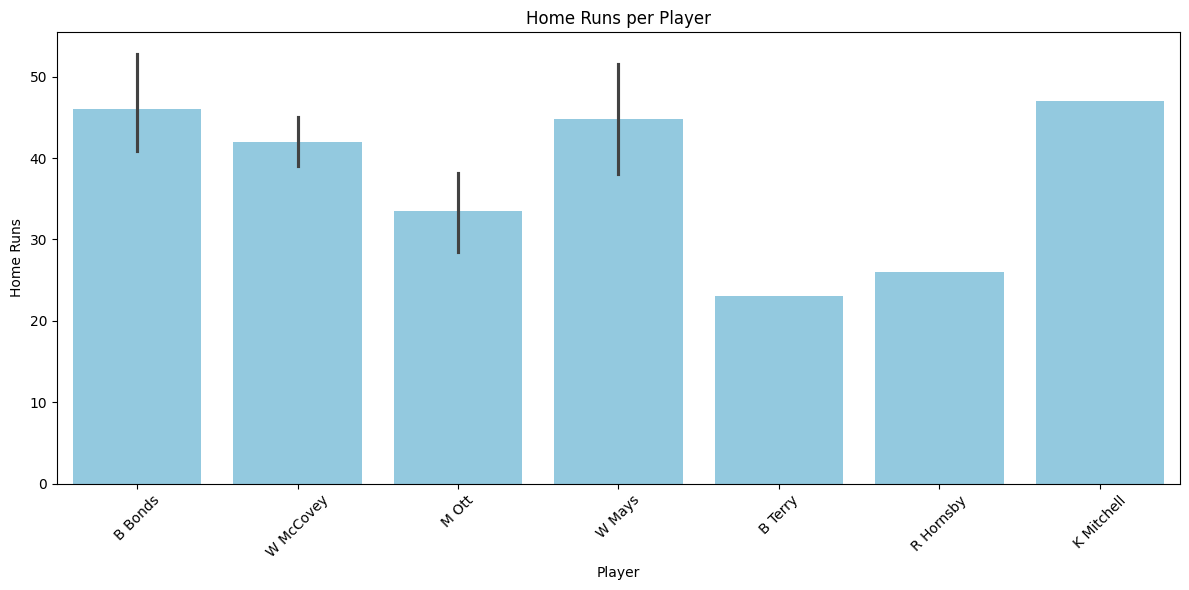

In [21]:
# Bar Plot: Total Home Runs per Player

plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='PLAYER', y='HR', color='skyblue')
plt.title('Home Runs per Player')
plt.xlabel('Player')
plt.ylabel('Home Runs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


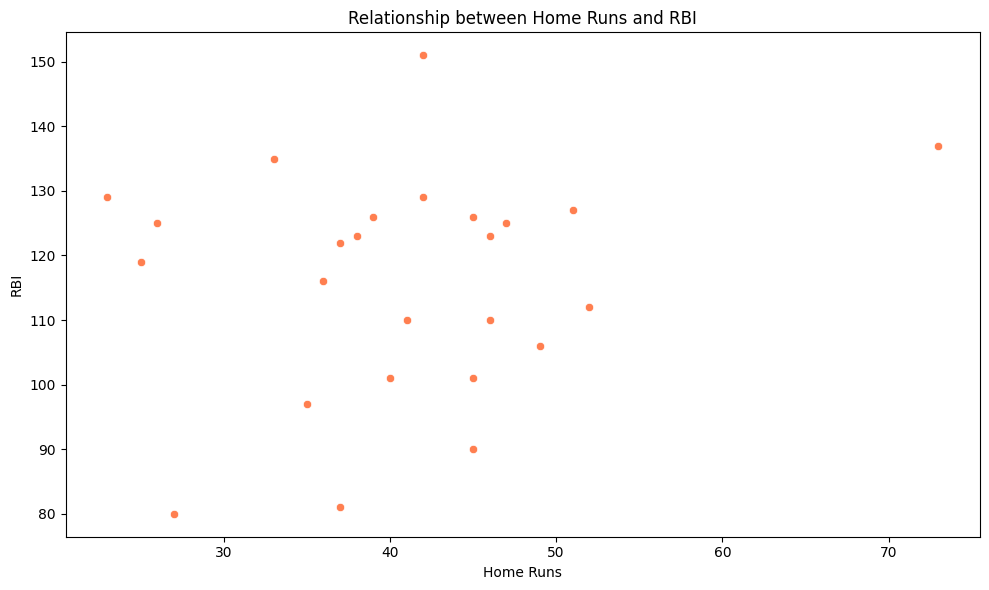

In [22]:
# Scatter Plot: Home Runs vs. RBI

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='HR', y='RBI', color='coral')
plt.title('Relationship between Home Runs and RBI')
plt.xlabel('Home Runs')
plt.ylabel('RBI')
plt.tight_layout()
plt.show()
